In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/tejasshukla/cms-gan-generator/generator.weights.h5
/kaggle/input/datasets/tejasshukla/cms-super-resolution/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet
/kaggle/input/datasets/tejasshukla/cms-super-resolution/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540_LR.parquet
/kaggle/input/datasets/tejasshukla/cms-super-resolution/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
!pip install pyarrow

In [4]:
import tensorflow as tf

2026-03-29 12:53:53.475605: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774788833.667943      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774788833.728843      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774788834.200709      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774788834.200752      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774788834.200754      55 computation_placer.cc:177] computation placer alr

# Exploring the dataset
This sections explores the given dataset to get an understanding of the data being worked with.

In [5]:
import pyarrow.parquet as pq

filepath = '/kaggle/input/datasets/tejasshukla/cms-super-resolution/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet'

parquet_file = pq.ParquetFile(filepath)


print("Columns:")
print(parquet_file.schema.names)
print("-" * 30)

first_batch = next(parquet_file.iter_batches(batch_size=5))

df_head = first_batch.to_pandas()

display(df_head)

Columns:
['element', 'element', 'pt', 'm0', 'y']
------------------------------


,X_jets_LR,X_jets,pt,m0,y
0,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",112.411095,21.098248,0.0
1,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",95.220406,14.030600,1.0
2,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",97.007317,17.728968,1.0
3,"[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...","[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0...",82.490311,14.702741,0.0
4,"[[[0.0, 0.0, 0.0, 0.0, 0.08212081342935562, 0....","[[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.328483...",102.539238,19.456257,0.0


In [6]:
print("All available columns:", df_head.columns.tolist())

All available columns: ['X_jets_LR', 'X_jets', 'pt', 'm0', 'y']


In [11]:
print(parquet_file.schema)
print("\n" + "="*40 + "\n")

first_batch = next(parquet_file.iter_batches(batch_size=1))
df_single_row = first_batch.to_pandas()

for col in df_single_row.columns:
    data = df_single_row[col].iloc[0]
    print(f"Column: '{col}'")
    print(f"  Base Type: {type(data)}")
    
    if isinstance(data, np.ndarray):
        print(f"  NumPy Shape: {data.shape}")
        print(f"  Inner Data Type: {data.dtype}")
        
    elif isinstance(data, list):
        print(f"  List Length: {len(data)}")
        if len(data) > 0:
            print(f"  Type of element 0: {type(data[0])}")
          
            if isinstance(data[0], (list, np.ndarray)):
                print(f"  Shape/Length of element 0: {np.shape(data[0])}")
                
    else: 
        print(f"  Value: {data}")
        
    print("-" * 30)

required group field_id=-1 schema {
  optional group field_id=-1 X_jets_LR (List) {
    repeated group field_id=-1 list {
      optional group field_id=-1 element (List) {
        repeated group field_id=-1 list {
          optional group field_id=-1 element (List) {
            repeated group field_id=-1 list {
              optional double field_id=-1 element;
            }
          }
        }
      }
    }
  }
  optional group field_id=-1 X_jets (List) {
    repeated group field_id=-1 list {
      optional group field_id=-1 element (List) {
        repeated group field_id=-1 list {
          optional group field_id=-1 element (List) {
            repeated group field_id=-1 list {
              optional double field_id=-1 element;
            }
          }
        }
      }
    }
  }
  optional double field_id=-1 pt;
  optional double field_id=-1 m0;
  optional double field_id=-1 y;
}



Column: 'X_jets_LR'
  Base Type: <class 'numpy.ndarray'>
  NumPy Shape: (3,)
  Inner Data Type:

In [12]:
lr_raw = df_single_row['X_jets_LR'].iloc[0]
hr_raw = df_single_row['X_jets'].iloc[0]

print("LOW-RES CHANNELS")
for i in range(3):
    channel_data = lr_raw[i]
    print(f"Channel {i}:")
    print(f"  Type: {type(channel_data)}")
    
    if isinstance(channel_data, np.ndarray):
        print(f"  Shape: {channel_data.shape}")
        print(f"  First 5 values: {channel_data.flatten()[:5]}")
    elif isinstance(channel_data, list):
        print(f"  Length (Number of items): {len(channel_data)}")
        if len(channel_data) > 0:
            print(f"  First item looks like: {channel_data[0]}")
    print("-" * 20)

LOW-RES CHANNELS
Channel 0:
  Type: <class 'numpy.ndarray'>
  Shape: (64,)
  First 5 values: [array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
 array([0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.19914806, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
      

Tensor Shape : (3, 64, 64)
Visual Image Shape: (64, 64, 3)



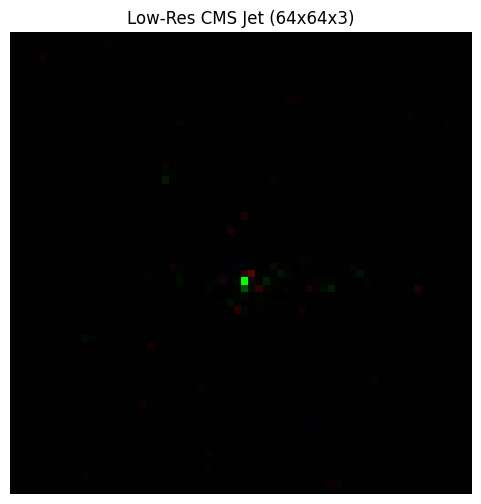

In [13]:
lr_matrix = np.stack([np.stack(channel) for channel in lr_raw])
print(f"Tensor Shape : {lr_matrix.shape}")

lr_img = np.transpose(lr_matrix, (1, 2, 0))
print(f"Visual Image Shape: {lr_img.shape}\n")

plt.figure(figsize=(6, 6))
lr_vis = (lr_img - np.min(lr_img)) / (np.max(lr_img) - np.min(lr_img) + 1e-8)

plt.imshow(lr_vis)
plt.title("Low-Res CMS Jet (64x64x3)")
plt.axis('off')
plt.show()

In [10]:
print("HIGH-RES CHANNELS")
for i in range(3):
    channel_data = hr_raw[i]
    print(f"Channel {i}:")
    print(f"  Type: {type(channel_data)}")
    print("-" * 20)

HIGH-RES CHANNELS
Channel 0:
  Type: <class 'numpy.ndarray'>
--------------------
Channel 1:
  Type: <class 'numpy.ndarray'>
--------------------
Channel 2:
  Type: <class 'numpy.ndarray'>
--------------------


In [11]:
print("HIGH-RES CHANNELS")
for i in range(3):
    channel_data = hr_raw[i]
    print(f"  Shape: {channel_data.shape}")
    print(f"  First 5 values: {channel_data.flatten()[:5]}")
    print("-" * 20)

HIGH-RES CHANNELS
  Shape: (125,)
  First 5 values: [array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0.])
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
   

Scientific Tensor Shape: (3, 125, 125)
Visual Image Shape: (125, 125, 3)



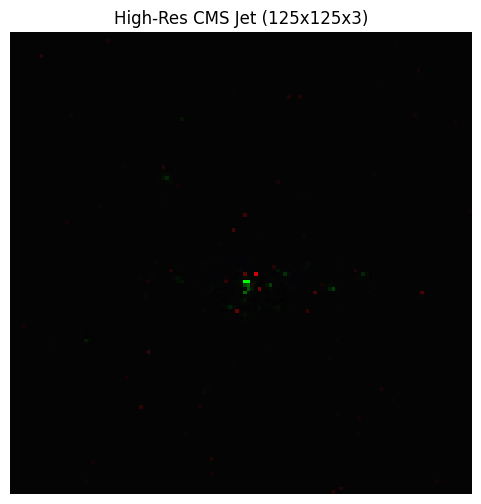

In [12]:
hr_matrix = np.stack([np.stack(channel) for channel in hr_raw])
print(f"Scientific Tensor Shape: {hr_matrix.shape}")

hr_img = np.transpose(hr_matrix, (1, 2, 0))
print(f"Visual Image Shape: {hr_img.shape}\n")

plt.figure(figsize=(6, 6))
hr_vis = (hr_img - np.min(hr_img)) / (np.max(hr_img) - np.min(hr_img) + 1e-8)

plt.imshow(hr_vis)
plt.title("High-Res CMS Jet (125x125x3)")
plt.axis('off')
plt.show()

# Dataset Pipeline


In [7]:
file_paths = [
    '/kaggle/input/datasets/tejasshukla/cms-super-resolution/QCDToGGQQ_IMGjet_RH1all_jet0_run0_n36272_LR.parquet',
    '/kaggle/input/datasets/tejasshukla/cms-super-resolution/QCDToGGQQ_IMGjet_RH1all_jet0_run1_n47540_LR.parquet',
    '/kaggle/input/datasets/tejasshukla/cms-super-resolution/QCDToGGQQ_IMGjet_RH1all_jet0_run2_n55494_LR.parquet'
]
# The first two files in file_paths would make the training dataset and the third file would make the validation dataset
train_files = file_paths[:2]  
test_files = [file_paths[2]]  

def cms_data_generator(files):
    for file in files:
        parquet_file = pq.ParquetFile(file)
        
        for batch in parquet_file.iter_batches(batch_size=100):
            df_batch = batch.to_pandas()
            
            for _, row in df_batch.iterrows():
                lr_raw = row['X_jets_LR']
                lr_stacked = np.stack([np.stack(c) for c in lr_raw])
                lr_img = np.transpose(lr_stacked, (1, 2, 0))
                
                hr_raw = row['X_jets']
                hr_stacked = np.stack([np.stack(c) for c in hr_raw])
                hr_img = np.transpose(hr_stacked, (1, 2, 0))
                
                lr_img = np.clip(lr_img / np.max(lr_img + 1e-8), 0, 1) 
                hr_img = np.clip(hr_img / np.max(hr_img + 1e-8), 0, 1)
                
                yield np.array(lr_img, dtype=np.float32), np.array(hr_img, dtype=np.float32)

def build_dataset(file_list, batch_size=8, is_training=True):
    ds = tf.data.Dataset.from_generator(
        lambda: cms_data_generator(file_list),
        output_signature=(
            tf.TensorSpec(shape=(64, 64, 3), dtype=tf.float32),   
            tf.TensorSpec(shape=(125, 125, 3), dtype=tf.float32)  
        )
    )
    if is_training:
        ds = ds.shuffle(buffer_size=500)
    
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(train_files, batch_size=8, is_training=True)
test_dataset = build_dataset(test_files, batch_size=8, is_training=False)

print("Training & Testing Pipelines successfully assembled!")

for lr_test, hr_test in train_dataset.take(1):
    print(f"Train Batch LR Shape: {lr_test.shape}")
    print(f"Train Batch HR Shape: {hr_test.shape}")

I0000 00:00:1774789355.430789      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Training & Testing Pipelines successfully assembled!
Train Batch LR Shape: (8, 64, 64, 3)
Train Batch HR Shape: (8, 125, 125, 3)


# The Model

The model trained in this project is a Generative Adversarial Network (GAN). This model is inspired from this research paper: https://www.sciencedirect.com/science/article/pii/S0925231225008744

##     1. Generator


In [15]:
from tensorflow.keras.layers import Conv2D, LeakyReLU, Concatenate, Add
from tensorflow.keras.initializers import HeNormal

def dense_block(input_tensor, filters=64, gc=32, residual_scaling=0.2):
    init = HeNormal()
    x1 = Conv2D(gc, kernel_size=3, strides=1, padding='same', kernel_initializer=init)(input_tensor)
    x1 = LeakyReLU(alpha=0.2)(x1)

    c2 = Concatenate()([input_tensor, x1])
    x2 = Conv2D(gc, kernel_size=3, strides=1, padding='same', kernel_initializer=init)(c2)
    x2 = LeakyReLU(alpha=0.2)(x2)

    c3 = Concatenate()([input_tensor, x1, x2])
    x3 = Conv2D(gc, kernel_size=3, strides=1, padding='same', kernel_initializer=init)(c3)
    x3 = LeakyReLU(alpha=0.2)(x3)

    c4 = Concatenate()([input_tensor, x1, x2, x3])
    x4 = Conv2D(filters, kernel_size=3, strides=1, padding='same', kernel_initializer=init)(c4)

    scaled_output = x4 * residual_scaling
    output = Add()([input_tensor, scaled_output])
    return output

In [16]:
def rrdb_block(input_tensor, filters = 64, gc = 32, residual_scaling = 0.2):
    out = dense_block(input_tensor, filters, gc, residual_scaling)
    out = dense_block(out, filters, gc, residual_scaling)
    out = dense_block(out, filters, gc, residual_scaling)

    scaled_out = out*residual_scaling
    output = Add()([input_tensor, scaled_out])
    return output

In [17]:
from tensorflow.keras.layers import Input, LeakyReLU, UpSampling2D
from tensorflow.keras.models import Model

In [18]:
def build_generator(input_shape = (64,64,3), n_rrdb = 2):
    inputs = Input(shape = input_shape)
    x = Conv2D(64, kernel_size = 3, strides = 1, padding = 'same')(inputs)
    
    x_bypass = x
    for _ in range (n_rrdb):
        x = rrdb_block(x, filters = 64, gc = 32, residual_scaling = 0.2)

    x = Conv2D(64, kernel_size = 3, strides = 1, padding = 'same')(x)
    x = Add()([x_bypass, x])
    up = UpSampling2D(size = (2,2), interpolation = 'nearest')(x)
    x = Conv2D(64, kernel_size = 4, strides = 1, padding = 'valid')(up)
    x = LeakyReLU(negative_slope=0.2)(x)
    outputs = Conv2D(3, kernel_size=3, strides=1, padding='same', activation='linear')(x)

    return Model(inputs, outputs, name = 'RDL_Generator')

generator = build_generator()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


## 2. Discriminator  

In [18]:
from tensorflow.keras.layers import ZeroPadding2D, Cropping2D, SpectralNormalization


In [19]:
def block1(x, filters):
    x = SpectralNormalization(Conv2D(filters, kernel_size=3, strides=1, padding='same'))(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    
    x = SpectralNormalization(Conv2D(filters, kernel_size=3, strides=2, padding='same'))(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    
    return x

def block2(x, skip_tensor, filters):
    x = UpSampling2D(size=(2, 2), interpolation='bilinear')(x)
    
    x = Concatenate()([x, skip_tensor])

    x = SpectralNormalization(Conv2D(filters, kernel_size=3, strides=1, padding='same'))(x)
    x = LeakyReLU(negative_slope=0.2)(x)
    
    x = SpectralNormalization(Conv2D(filters, kernel_size=3, strides=1, padding='same'))(x)
    x = LeakyReLU(negative_slope=0.2)(x)

    return x

def build_discriminator(input_shape = (125, 125, 3)):
    inputs = Input(shape = input_shape)
    padded_inputs = ZeroPadding2D(padding = ((1,2), (1,2)))(inputs)

    d1 = block1(padded_inputs, 32)
    d2 = block1(d1, 64)            
    d3 = block1(d2, 128)            
             
    u2 = block2(d3, d2, 64)         
    u3 = block2(u2, d1, 32)          
    u4 = block2(u3, padded_inputs, 16)

    out = Conv2D(1, kernel_size=1, strides=1, padding='same')(u4)
    out = tf.keras.layers.Activation('sigmoid')(out)
    output = Cropping2D(cropping=((1, 2), (1, 2)))(out)
    return Model(inputs, output, name="UNet_Discriminator")

discriminator = build_discriminator()

# Loss functions


In [30]:
# This loss is employed to prevent mode collapse of the model generating an all-black image.
# This loss highly penalizes the model for missing bright pixels.
def sparse_weighted_me_loss(y_true, y_pred, nonzero_weight=5000.0):
    
    mask = tf.cast(y_true > 0.0, tf.float32)
    weight_map = 1.0 + (nonzero_weight - 1.0) * mask
    squared_error = tf.square(y_true - y_pred)

    loss = tf.reduce_mean(weight_map * squared_error)
    return loss

# Training 

## Generator pre-training 
This ensures that we have a good enough generator to train in the GAN model and that the model does not run into mode collapse

In [28]:
import time
from IPython.display import clear_output

In [ ]:
PRETRAIN_EPOCHS = 6  

for benchmark_lr, benchmark_hr in train_dataset.take(1):
    break

print("---  GENERATOR PRE-TRAINING  ---")
pretrain_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, clipnorm=1.0)
@tf.function
def pretrain_step(lr_images, hr_images):
    with tf.GradientTape() as tape:
        sr_images = generator(lr_images, training=True)
        loss = sparse_weighted_me_loss(hr_images, sr_images)
        
    grads = tape.gradient(loss, generator.trainable_variables)
    pretrain_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    
    batch_psnr = tf.reduce_mean(tf.image.psnr(hr_images, sr_images, max_val=1.0))
    return loss, batch_psnr

for epoch in range(PRETRAIN_EPOCHS):
    start_time = time.time()
    epoch_loss, epoch_psnr = 0.0, 0.0
    num_batches = 0
    
    for step, (lr_batch, hr_batch) in enumerate(train_dataset):
        loss, batch_psnr = pretrain_step(lr_batch, hr_batch)
        epoch_loss += loss
        epoch_psnr += batch_psnr
        num_batches += 1
        if step % 2000 == 0: 
            print(f"Pretrain Epoch {epoch+1} | Batch {step} | Loss: {loss:.4f} | PSNR: {batch_psnr:.2f}")
    avg_loss = epoch_loss / num_batches
    avg_psnr = epoch_psnr / num_batches
    
    print(f"\n--- Pretrain Epoch {epoch+1} Completed in {time.time() - start_time:.1f} sec ---")
    print(f"Avg Loss: {avg_loss:.4f} | Avg PSNR: {avg_psnr:.2f}")

    # Ensurees that the network isn't outputting pure black
    sr_sample = generator(lr_batch[:4], training=False).numpy()
    print(f"  -> SR output mean: {sr_sample.mean():.8f}")
    print(f"  -> SR output max:  {sr_sample.max():.6f}")
    print(f"  -> HR nonzero frac: {(hr_batch.numpy() > 0).mean():.4f}")


    if (epoch + 1) % 2 == 0:
        clear_output(wait=True) 
        generated_benchmark = generator(benchmark_lr, training=False)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(benchmark_lr[0].numpy())
        axes[0].set_title(f"Pretrain Epoch {epoch+1} - LR Input")
        axes[0].axis('off')
        
        axes[1].imshow(generated_benchmark[0].numpy())
        axes[1].set_title("Pretrain SR Output")
        axes[1].axis('off')
        
        axes[2].imshow(benchmark_hr[0].numpy())
        axes[2].set_title("High-Res Target")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

In [ ]:
# Image generated by the generator after pre-training.
current_output = generator(benchmark_lr, training=False)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(benchmark_lr[0].numpy())
axes[0].set_title("Low-Res Input")
axes[0].axis('off')

axes[1].imshow(current_output[0].numpy())
axes[1].set_title("Current SR Output")
axes[1].axis('off')

axes[2].imshow(benchmark_hr[0].numpy())
axes[2].set_title("High-Res Target")
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Saving generator weights after pre-training
generator.save_weights('generator_paused.weights.h5')
print("Saved!")

## Generative Adversarial Network (GAN) training

In [ ]:
from tensorflow.keras.losses import BinaryCrossentropy, MeanAbsoluteError
lambda1 = 1.0
lambda2 = 0.005
bce_loss = BinaryCrossentropy()
l1_loss = MeanAbsoluteError()
# Discriminator has a lower learning rate so that it does not overpower the generator. 
# Rest of the hyperparameters have been taken from the research paper.
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4, beta_1=0.9, beta_2=0.999, clipnorm=1.0)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=5e-5, beta_1=0.9, beta_2=0.999, clipnorm=1.0)

@tf.function
def train_step(lr_images, hr_images):
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(lr_images, training = True)
        real_output = discriminator(hr_images, training = True)
        fake_output = discriminator(generated_images, training = True)

        real_labels = tf.ones_like(real_output) * 0.9
        fake_labels = tf.zeros_like(fake_output) + 0.1

        # Discriminator loss
        disc_real_loss = bce_loss(real_labels, real_output)
        disc_fake_loss = bce_loss(fake_labels, fake_output)
        disc_total_loss = disc_real_loss + disc_fake_loss

        # Generator loss
        l_recons = sparse_weighted_me_loss(hr_images, generated_images) # Pixel-wise reconstruction loss
        l_adv = bce_loss(real_labels, fake_output) # Adversarial loss
        
        gen_total_loss = lambda1 * l_recons + lambda2 * l_adv
        batch_psnr = tf.reduce_mean(tf.image.psnr(hr_images, generated_images, max_val=1.0))

    gen_gradients = gen_tape.gradient(gen_total_loss, generator.trainable_variables)
    disc_gradients = disc_tape.gradient(disc_total_loss, discriminator.trainable_variables)
    
    generator_optimizer.apply_gradients(zip(gen_gradients, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(disc_gradients, discriminator.trainable_variables))
    
    return gen_total_loss, disc_total_loss, batch_psnr

In [ ]:
GAN_EPOCHS = 30
print("\n--- FULL GAN TRAINING ---")

for epoch in range(GAN_EPOCHS):
    start_time = time.time()
    epoch_g_loss, epoch_d_loss, epoch_psnr = 0.0, 0.0, 0.0
    num_batches = 0
    
    for step, (lr_batch, hr_batch) in enumerate(train_dataset):
        # Using your existing adversarial train_step
        g_loss, d_loss, batch_psnr = train_step(lr_batch, hr_batch)
        
        epoch_g_loss += g_loss
        epoch_d_loss += d_loss
        epoch_psnr += batch_psnr
        num_batches += 1
        if step % 1000 == 0:
            print(f"  Batch {step} | G_Loss: {g_loss:.4f} | D_Loss: {d_loss:.4f}")
        
    avg_g_loss = epoch_g_loss / num_batches
    avg_d_loss = epoch_d_loss / num_batches
    avg_psnr = epoch_psnr / num_batches
    
    print(f"\n--- GAN Epoch {epoch+1} Completed in {time.time() - start_time:.1f} sec ---")
    print(f"Avg G_Loss: {avg_g_loss:.4f} | Avg D_Loss: {avg_d_loss:.4f} | Avg PSNR: {avg_psnr:.2f}")
    

    if (epoch + 1) % 5 == 0:
        clear_output(wait=True) 
        generated_benchmark = generator(benchmark_lr, training=False)
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(benchmark_lr[0].numpy())
        axes[0].set_title(f"GAN Epoch {epoch+1} - LR Input")
        axes[0].axis('off')
        
        axes[1].imshow(generated_benchmark[0].numpy())
        axes[1].set_title("GAN SR Output")
        axes[1].axis('off')
        
        axes[2].imshow(benchmark_hr[0].numpy())
        axes[2].set_title("High-Res Target")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()

In [ ]:
# Saving generator weights after GAN training. 
generator.save_weights('generator.weights.h5')
print("Saved!")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(benchmark_lr[0].numpy())
axes[0].set_title("LR Input")
axes[0].axis('off')
        
axes[1].imshow(generated_benchmark[0].numpy())
axes[1].set_title("GAN SR Output")
axes[1].axis('off')
        
axes[2].imshow(benchmark_hr[0].numpy())
axes[2].set_title("High-Res Target")
axes[2].axis('off')
        
plt.tight_layout()
plt.show()

# Testing

Loading the weights trained in the previous section.

In [19]:
generator.load_weights('/kaggle/input/datasets/tejasshukla/cms-gan-generator/generator.weights.h5')
print("Loaded!")

Loaded!


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.08016465..0.7018354].


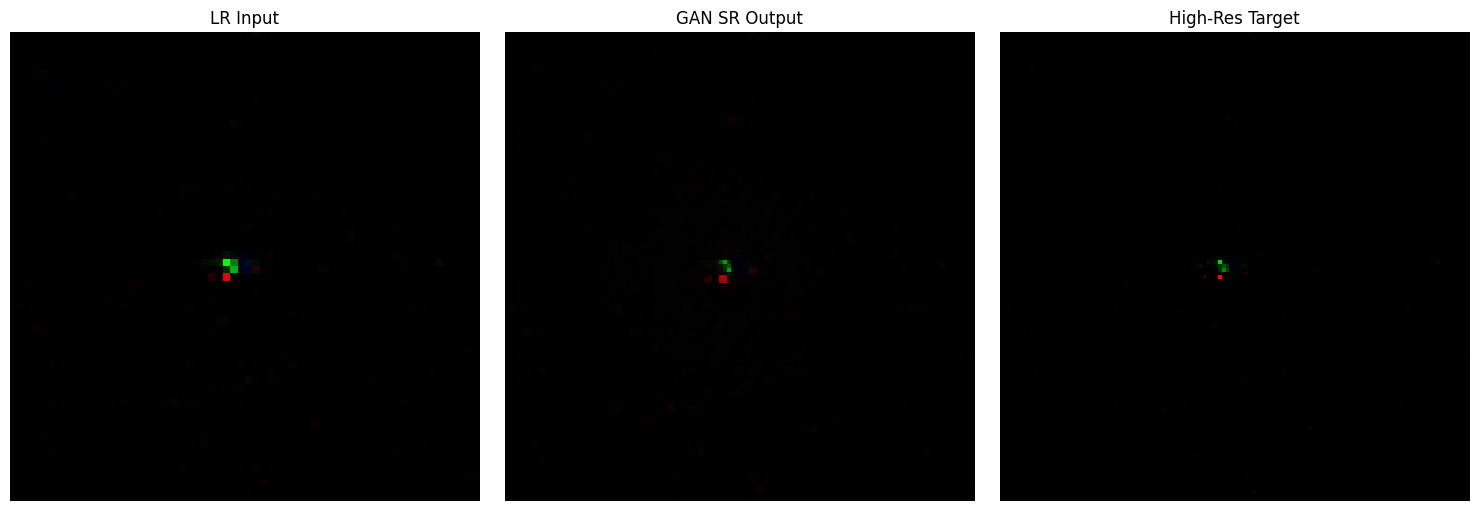

In [26]:
for benchmark_lr, benchmark_hr in train_dataset.take(1):
    break

generated_benchmark = generator(benchmark_lr, training=False)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(benchmark_lr[2].numpy())
axes[0].set_title("LR Input")
axes[0].axis('off')
        
axes[1].imshow(generated_benchmark[2].numpy())
axes[1].set_title("GAN SR Output")
axes[1].axis('off')
        
axes[2].imshow(benchmark_hr[2].numpy())
axes[2].set_title("High-Res Target")
axes[2].axis('off')
        
plt.tight_layout()
plt.show()

In [21]:
sr_energy_residuals, lr_energy_residuals = [], []
psnr_scores, ssim_scores = [], []

print("--- TESTING ---")

for step, (lr_batch, hr_batch) in enumerate(test_dataset): 
    
    sr_batch = generator(lr_batch, training=False)
    

    sr_clean = tf.where(sr_batch < 0.01, 0.0, sr_batch)
    hr_clean = tf.where(hr_batch < 0.01, 0.0, hr_batch)


    batch_psnr = tf.image.psnr(hr_clean, sr_clean, max_val=1.0)
    batch_ssim = tf.image.ssim(hr_clean, sr_clean, max_val=1.0)
    
    psnr_scores.extend(batch_psnr.numpy())
    ssim_scores.extend(batch_ssim.numpy())
    

    lr_energy_sum = tf.reduce_sum(lr_batch, axis=[1, 2, 3])
    hr_energy_sum = tf.reduce_sum(hr_clean, axis=[1, 2, 3])
    sr_energy_sum = tf.reduce_sum(sr_clean, axis=[1, 2, 3])
    
    sr_res = (sr_energy_sum - hr_energy_sum) / (hr_energy_sum + 1e-8)
    lr_res = (lr_energy_sum - hr_energy_sum) / (hr_energy_sum + 1e-8)
    
    sr_energy_residuals.extend(sr_res.numpy())
    lr_energy_residuals.extend(lr_res.numpy())

    if (step + 1) % 300 == 0:
        print(f"Processed {step} batches...")




--- TESTING ---
Processed 299 batches...
Processed 599 batches...
Processed 899 batches...
Processed 1199 batches...
Processed 1499 batches...
Processed 1799 batches...
Processed 2099 batches...
Processed 2399 batches...
Processed 2699 batches...
Processed 2999 batches...
Processed 3299 batches...
Processed 3599 batches...
Processed 3899 batches...
Processed 4199 batches...
Processed 4499 batches...
Processed 4799 batches...
Processed 5099 batches...
Processed 5399 batches...
Processed 5699 batches...
Processed 5999 batches...
Processed 6299 batches...
Processed 6599 batches...
Processed 6899 batches...


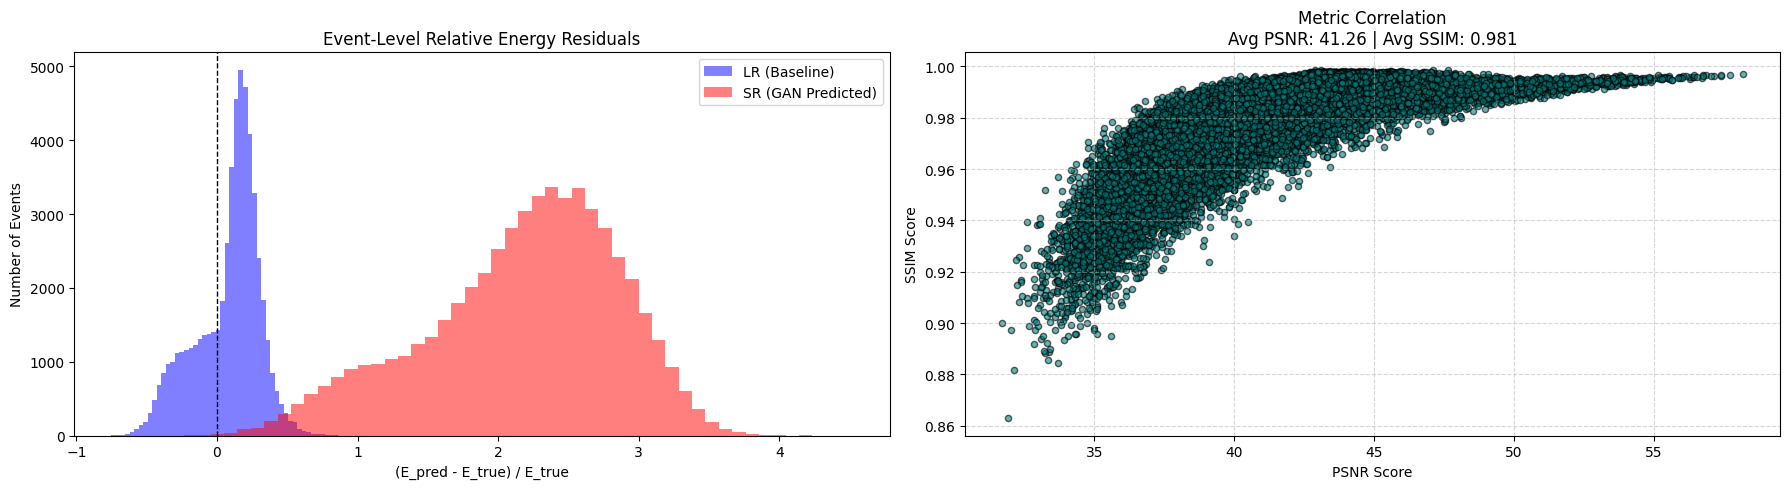

In [22]:
fig = plt.figure(figsize=(18, 5))

# Histogram 
ax1 = plt.subplot(1, 2, 1)
ax1.hist(lr_energy_residuals, bins=50, alpha=0.5, label='LR (Baseline)', color='blue')
ax1.hist(sr_energy_residuals, bins=50, alpha=0.5, label='SR (GAN Predicted)', color='red')
ax1.set_title("Event-Level Relative Energy Residuals")
ax1.set_xlabel("(E_pred - E_true) / E_true")
ax1.set_ylabel("Number of Events")
ax1.legend()
ax1.axvline(0, color='black', linestyle='dashed', linewidth=1)



ax2 = plt.subplot(1, 2, 2)
ax2.scatter(psnr_scores, ssim_scores, alpha=0.6, color='teal', edgecolors='k', s=20)
ax2.set_title(f"Metric Correlation\nAvg PSNR: {np.mean(psnr_scores):.2f} | Avg SSIM: {np.mean(ssim_scores):.3f}")
ax2.set_xlabel("PSNR Score")
ax2.set_ylabel("SSIM Score")
ax2.grid(True, linestyle='--', alpha=0.5)

sample_hr = hr_clean[1].numpy()
sample_sr = sr_clean[1].numpy()
difference_map = np.abs(sample_hr - sample_sr)

plt.tight_layout()
plt.show()

# Analysis

The model performs well on the **PSNR** and **SSIM** metrics, indicating that the predicted super-resolution (**SR**) images (cell energies) are pixel-wise and structurally similar to the ground truth high-resolution (**HR**) images (cell energies). 

However, the model does not perform well when we consider the **event-level relative energy residuals** of the LR cell energies and the predicted SR cell energies. 

The peak of the **red histogram** should be more towards the left, preferably towards the left of the peak of the **blue histogram** for the model to be effective for super-resolution. 

Since the GAN model's predictions perform well on the **SSIM** and **PSNR** metrics, only the **Generator** needs to be refined a bit more rather than training the whole GAN again. This is done by introducing a new loss function:

$$
l_{\text{energy}} = \left| \, lr_{\text{energy}} - sr_{\text{energy}} \, \right|
$$
where:

- $lr_{\text{energy}}$ = sum of all LR cell energies  
- $sr_{\text{energy}}$ = sum of all SR cell energies  


In [43]:
print("--- PHYSICS FINE-TUNING ---")


finetune_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5, clipnorm=1.0)

lambda_energy = 2.0  

@tf.function
def physics_align_step(lr_images, hr_images):
    with tf.GradientTape() as tape:
        sr_images = generator(lr_images, training=True)
        

        sr_clean = tf.nn.relu(sr_images - 0.01)
        
        lr_energy = tf.reduce_sum(lr_images, axis=[1, 2, 3])
        sr_energy = tf.reduce_sum(sr_clean, axis=[1, 2, 3])
        

        l_energy = tf.reduce_mean(tf.abs(lr_energy - sr_energy))
        l_recons = sparse_weighted_me_loss(hr_images, sr_images)
        total_loss = l_recons + (lambda_energy * l_energy)
        
    grads = tape.gradient(total_loss, generator.trainable_variables)
    finetune_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    
    return total_loss, l_energy, l_recons




--- PHYSICS FINE-TUNING ---


In [49]:
# Ran for 3 epochs and then finally, 1 more epoch
PHY_EPOCHS = 1


for epoch in range(PHY_EPOCHS):
    start_time = time.time()
    epoch_loss, epoch_e_loss = 0.0, 0.0
    num_batches = 0
    
    for step, (lr_batch, hr_batch) in enumerate(train_dataset):
        t_loss, e_loss, r_loss = physics_align_step(lr_batch, hr_batch)
        
        epoch_loss += t_loss
        epoch_e_loss += e_loss
        num_batches += 1
        
        if step % 1000 == 0:
            print(f"  Batch {step} | Total Loss: {t_loss:.4f} | Physics Error: {e_loss:.4f}")
            
    avg_loss = epoch_loss / num_batches
    avg_e_loss = epoch_e_loss / num_batches
    print(f"--- Epoch {epoch+1} Completed in {time.time() - start_time:.1f} sec ---")
    print(f"Avg Total Loss: {avg_loss:.4f} | Avg Physics Error: {avg_e_loss:.4f}\n")

  Batch 0 | Total Loss: 0.3913 | Physics Error: 0.1467
  Batch 1000 | Total Loss: 0.2212 | Physics Error: 0.0842
  Batch 2000 | Total Loss: 0.3630 | Physics Error: 0.1218
  Batch 3000 | Total Loss: 0.3816 | Physics Error: 0.1422
  Batch 4000 | Total Loss: 0.2611 | Physics Error: 0.0842
  Batch 5000 | Total Loss: 0.2195 | Physics Error: 0.0627
  Batch 6000 | Total Loss: 0.2825 | Physics Error: 0.0777
  Batch 7000 | Total Loss: 0.2231 | Physics Error: 0.0685
  Batch 8000 | Total Loss: 0.2249 | Physics Error: 0.0759
  Batch 9000 | Total Loss: 0.4203 | Physics Error: 0.1488
  Batch 10000 | Total Loss: 0.3736 | Physics Error: 0.1238
--- Epoch 1 Completed in 470.5 sec ---
Avg Total Loss: 0.3154 | Avg Physics Error: 0.1078



In [58]:
sr_energy_residuals, lr_energy_residuals = [], []
psnr_scores, ssim_scores = [], []

print("--- TESTING ---")

for step, (lr_batch, hr_batch) in enumerate(test_dataset): 
    
    sr_batch = generator(lr_batch, training=False)
    

    sr_clean = tf.where(sr_batch < 0.01, 0.0, sr_batch)
    hr_clean = tf.where(hr_batch < 0.01, 0.0, hr_batch)


    batch_psnr = tf.image.psnr(hr_clean, sr_clean, max_val=1.0)
    batch_ssim = tf.image.ssim(hr_clean, sr_clean, max_val=1.0)
    
    psnr_scores.extend(batch_psnr.numpy())
    ssim_scores.extend(batch_ssim.numpy())
    

    lr_energy_sum = tf.reduce_sum(lr_batch, axis=[1, 2, 3])
    hr_energy_sum = tf.reduce_sum(hr_clean, axis=[1, 2, 3])
    sr_energy_sum = tf.reduce_sum(sr_clean, axis=[1, 2, 3])
    
    sr_res = (sr_energy_sum - hr_energy_sum) / (hr_energy_sum + 1e-8)
    lr_res = (lr_energy_sum - hr_energy_sum) / (hr_energy_sum + 1e-8)
    
    sr_energy_residuals.extend(sr_res.numpy())
    lr_energy_residuals.extend(lr_res.numpy())

    if (step + 1) % 300 == 0:
        print(f"Processed {step} batches...")




--- TESTING ---
Processed 299 batches...
Processed 599 batches...
Processed 899 batches...
Processed 1199 batches...
Processed 1499 batches...
Processed 1799 batches...
Processed 2099 batches...
Processed 2399 batches...
Processed 2699 batches...
Processed 2999 batches...
Processed 3299 batches...
Processed 3599 batches...
Processed 3899 batches...
Processed 4199 batches...
Processed 4499 batches...
Processed 4799 batches...
Processed 5099 batches...
Processed 5399 batches...
Processed 5699 batches...
Processed 5999 batches...
Processed 6299 batches...
Processed 6599 batches...
Processed 6899 batches...


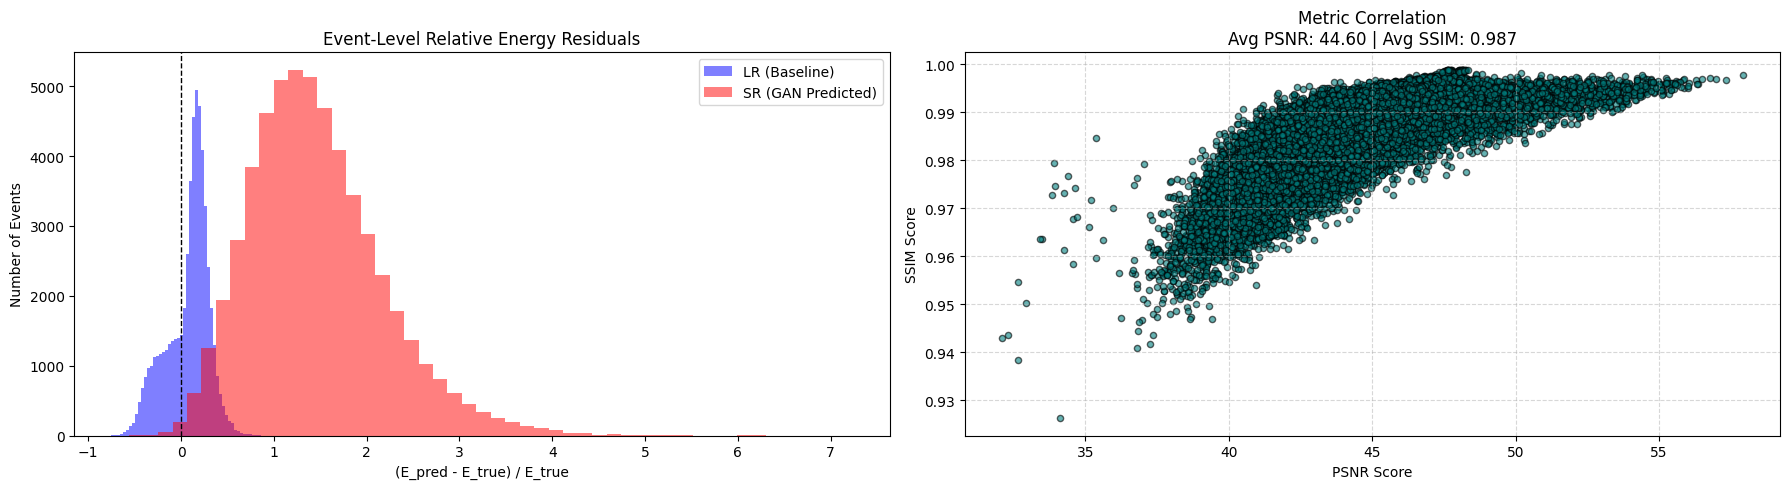

In [59]:
fig = plt.figure(figsize=(18, 5))

# Histogram 
ax1 = plt.subplot(1, 2, 1)
ax1.hist(lr_energy_residuals, bins=50, alpha=0.5, label='LR (Baseline)', color='blue')
ax1.hist(sr_energy_residuals, bins=50, alpha=0.5, label='SR (GAN Predicted)', color='red')
ax1.set_title("Event-Level Relative Energy Residuals")
ax1.set_xlabel("(E_pred - E_true) / E_true")
ax1.set_ylabel("Number of Events")
ax1.legend()
ax1.axvline(0, color='black', linestyle='dashed', linewidth=1)



ax2 = plt.subplot(1, 2, 2)
ax2.scatter(psnr_scores, ssim_scores, alpha=0.6, color='teal', edgecolors='k', s=20)
ax2.set_title(f"Metric Correlation\nAvg PSNR: {np.mean(psnr_scores):.2f} | Avg SSIM: {np.mean(ssim_scores):.3f}")
ax2.set_xlabel("PSNR Score")
ax2.set_ylabel("SSIM Score")
ax2.grid(True, linestyle='--', alpha=0.5)

sample_hr = hr_clean[1].numpy()
sample_sr = sr_clean[1].numpy()
difference_map = np.abs(sample_hr - sample_sr)

plt.tight_layout()
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.026240971..0.516391].


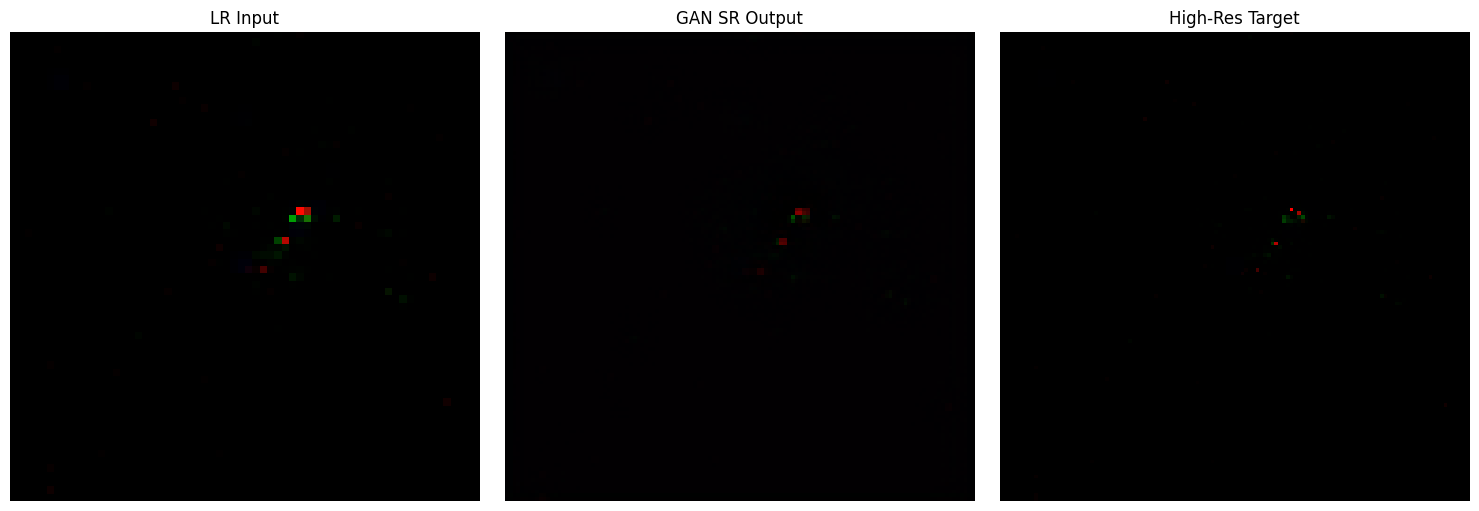

In [65]:
for benchmark_lr, benchmark_hr in train_dataset.take(1):
    break

generated_benchmark = generator(benchmark_lr, training=False)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(benchmark_lr[7].numpy())
axes[0].set_title("LR Input")
axes[0].axis('off')
        
axes[1].imshow(generated_benchmark[7].numpy())
axes[1].set_title("GAN SR Output")
axes[1].axis('off')
        
axes[2].imshow(benchmark_hr[7].numpy())
axes[2].set_title("High-Res Target")
axes[2].axis('off')
        
plt.tight_layout()
plt.show()

# Result 

The SR predicted cell energies perform well on super-resolution metrics with average **PSNR** = 44.60 and **SSIM** = 0.987.

The peak of the distribution of event-level relative energy residuals of the SR predicted cell energies shifted towards left and the distribution got narrower on introduction of the $l_{\text{energy}}$. This indicates improvement in the model and suggests that incorporating this loss function during the GAN training process may produce better results. 